This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820_all frames. The data was made in metashape using the refeernce method (needs to be updated). Last edits: 02/20/2026 BG

Continuous time series chunks 04/14/26

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

2026-04-23 12:44:37.130533: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# paths
MAE_datapath= r"/Volumes/kanarde/MasonBEAST/data/StormCHAZerz Data/Dec2023Noreaster_Processed/1702827001820_allframes/MAE"
# /Volumes/kanarde/MasonBEAST/data/StormCHAZerz Data/Dec2023Noreaster_Processed/1702827001820_allframes/MAE/Transects/1702827001820_allframes_7.3_2_raw.mat
# /Volumes/kanarde/MasonBEAST
transectpath=os.path.join(MAE_datapath,'Transects/')
rawdatapath=os.path.join(transectpath,'1702827001820_allframes_7.3_2_raw.mat')
autoencoderpath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_autoencoder') # update as needed for saving 
gausspath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_gauss') # update as needed for saving 
MAEpath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_MAE') # update as needed for saving 

In [3]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)

In [4]:
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe

In [57]:
print(transect_df_raw)

          0         1         2    3    4    5    6      7    8      9    ...  \
0         NaN       NaN  4.092429  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
1         NaN       NaN  4.092429  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
2         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
3         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
4         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
..        ...       ...       ...  ...  ...  ...  ...    ...  ...    ...  ...   
546  0.765234  0.822544  1.435690  NaN  NaN  NaN  NaN  0.997  NaN    NaN  ...   
547  0.761258  0.871067  1.430057  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
548  0.753258  0.958421  1.442268  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
549  0.764375  1.048709  1.487136  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
550  0.774625  1.163879       NaN  NaN  NaN  NaN  NaN  0.976  NaN  0.929  ...   

     229  230  231     232 

In [5]:
windows={} # window dictionary
window_idx={} # indexes

for timestep,transect in transect_df_raw.items():
    arg=transect.values
    masked=np.ma.masked_invalid(arg)
    clumps=np.ma.clump_unmasked(masked)

    windows[timestep]=[arg[s] for s in clumps]
    window_idx[timestep]=[(s.start,s.stop) for s in clumps]

    #print(f"Window length is: {len(arg)}") printing length of transect

Timestep: 0
Timestep: 1
Timestep: 2
Timestep: 3
Timestep: 4
Timestep: 5
Timestep: 6
Timestep: 7
Timestep: 8
Timestep: 9
Timestep: 10
Timestep: 11
Timestep: 12
Timestep: 13
Timestep: 14
Timestep: 15
Timestep: 16
Timestep: 17
Timestep: 18
Timestep: 19
Timestep: 20
Timestep: 21
Timestep: 22
Timestep: 23
Timestep: 24
Timestep: 25
Timestep: 26
Timestep: 27
Timestep: 28
Timestep: 29
Timestep: 30
Timestep: 31
Timestep: 32
Timestep: 33
Timestep: 34
Timestep: 35
Timestep: 36
Timestep: 37
Timestep: 38
Timestep: 39
Timestep: 40
Timestep: 41
Timestep: 42
Timestep: 43
Timestep: 44
Timestep: 45
Timestep: 46
Timestep: 47
Timestep: 48
Timestep: 49
Timestep: 50
Timestep: 51
Timestep: 52
Timestep: 53
Timestep: 54
Timestep: 55
Timestep: 56
Timestep: 57
Timestep: 58
Timestep: 59
Timestep: 60
Timestep: 61
Timestep: 62
Timestep: 63
Timestep: 64
Timestep: 65
Timestep: 66
Timestep: 67
Timestep: 68
Timestep: 69
Timestep: 70
Timestep: 71
Timestep: 72
Timestep: 73
Timestep: 74
Timestep: 75
Timestep: 76
Timestep:

break up continous sets into chosen length then build up masking ratio in MAE

In [6]:
# function to split up windows based on chosen threshold
# have windows slightly overlap

def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]



In [7]:
size=10 # chosen windwo size
split_windows_idx={}
# split windows to chosen length
for timestep in window_idx:
    newwindows=[]
    for (start,stop) in window_idx[timestep]:
        length=stop-start
        if length>=size: #skipping over windows less than chosen length
            newwindows.extend(window_split(start,stop,size,size/4)) # right now windows overlap 75%

    split_windows_idx[timestep]=newwindows

/var/folders/q5/f29tpv495_l1nlg9kcr2kl0w0000gx/T/ipykernel_89850/1213908068.py:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm,label='window length')


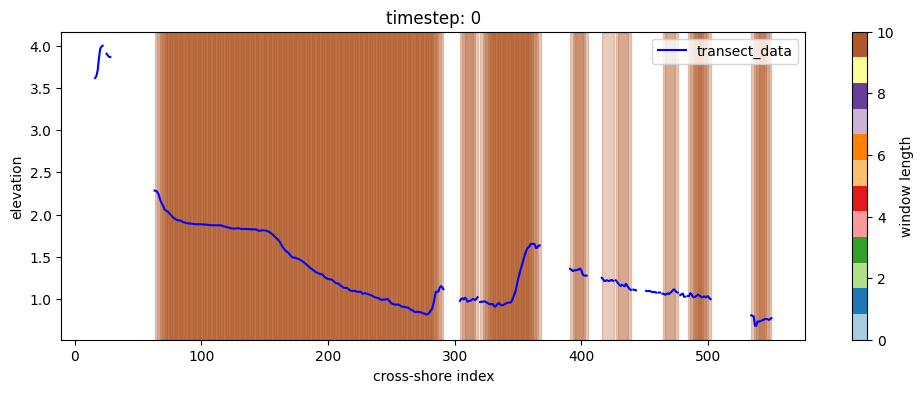

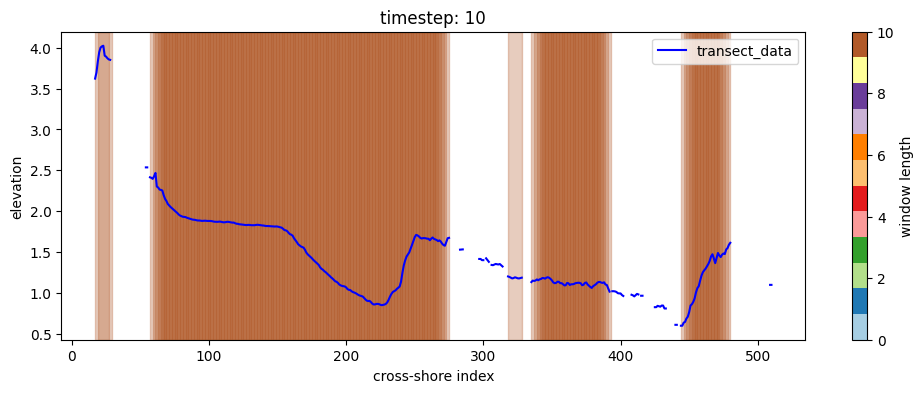

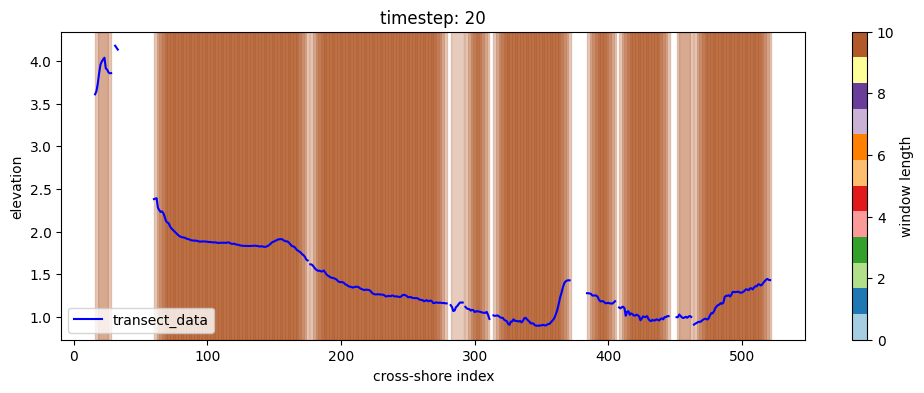

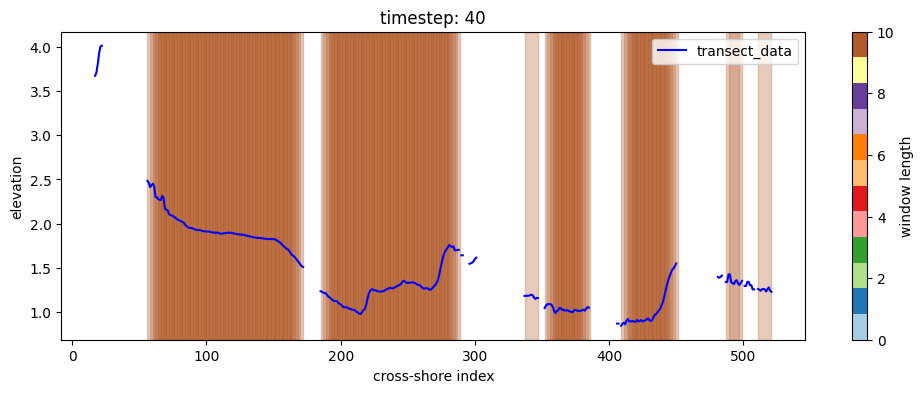

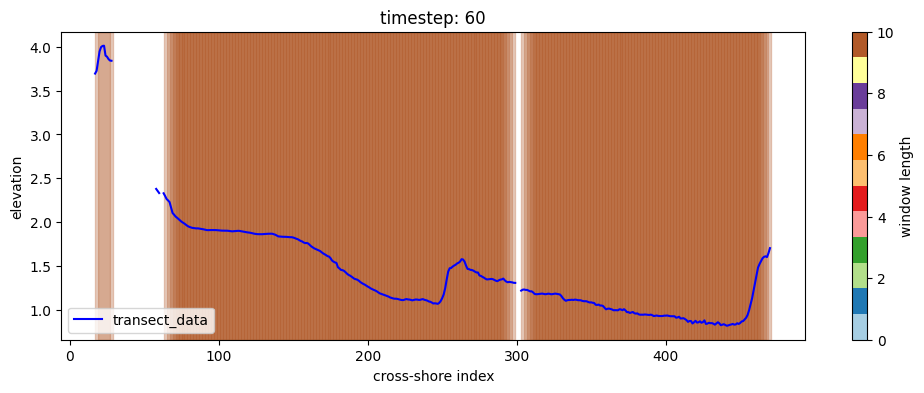

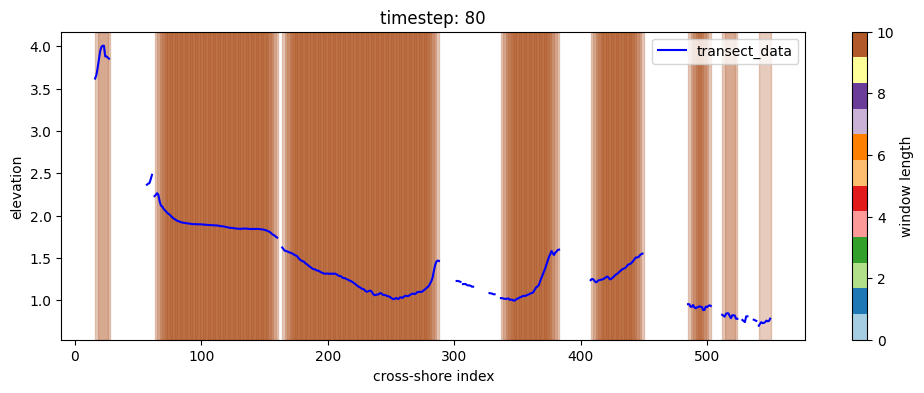

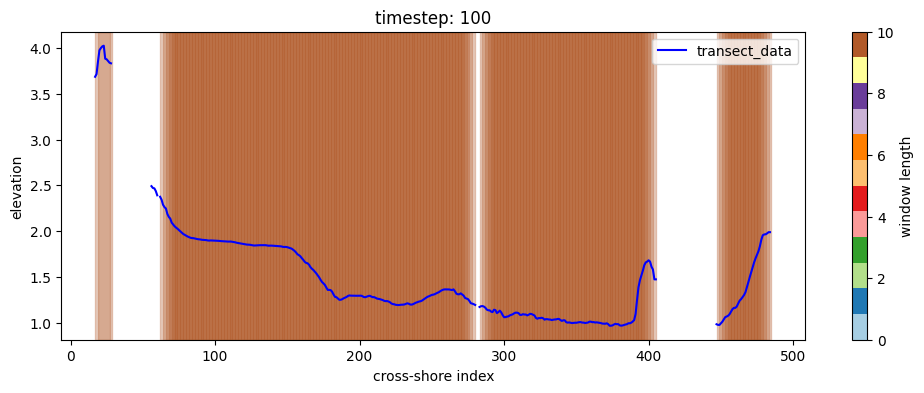

In [ ]:
# check function 
# plot the windows
timesteps=[0,10,20,40,60,80,100]

cmap=plt.cm.Paired
norm=plt.Normalize(0,size)

for timestep in timesteps:
    transect=transect_df_raw[timestep]

    aeta=transect.values
    crossDist=np.arange(len(aeta))

    plt.figure(figsize=(12,4))

    plt.plot(crossDist,aeta,color='blue',label='transect_data') # plot transect

    for (start,stop) in split_windows_idx[timestep]:
        length=stop-start
        color=cmap(norm(length))
        plt.axvspan(start,stop,color=color,alpha=0.3)

    plt.title(f"timestep: {timestep}")
    plt.xlabel("cross-shore index")
    plt.ylabel("elevation (m)")

    # color bar
    sm=plt.cm.ScalarMappable(cmap=cmap,norm=norm)
    sm.set_array([])
    plt.colorbar(sm,label='window length')
    plt.legend()

    plt.show()

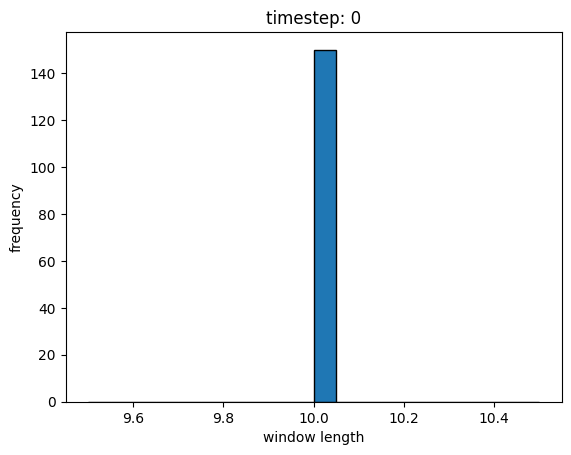

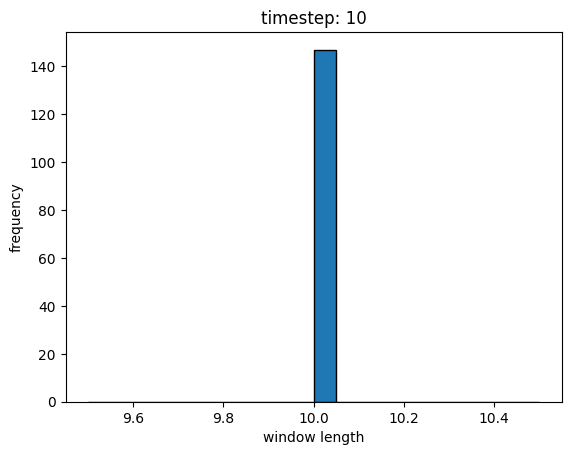

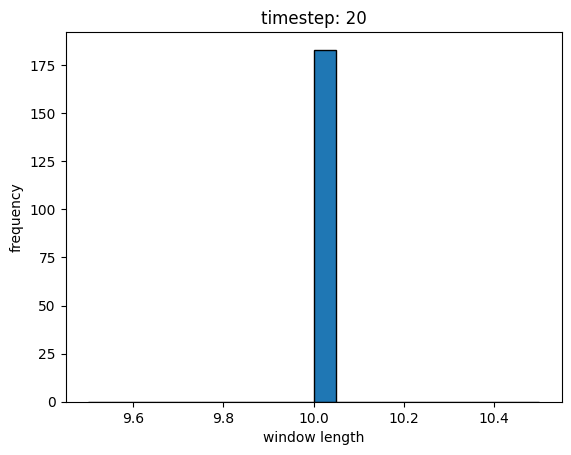

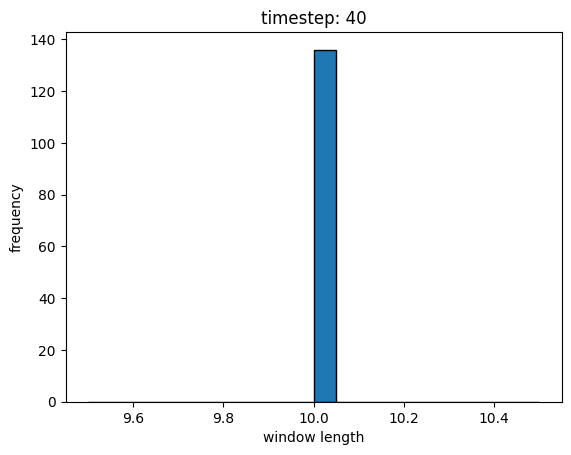

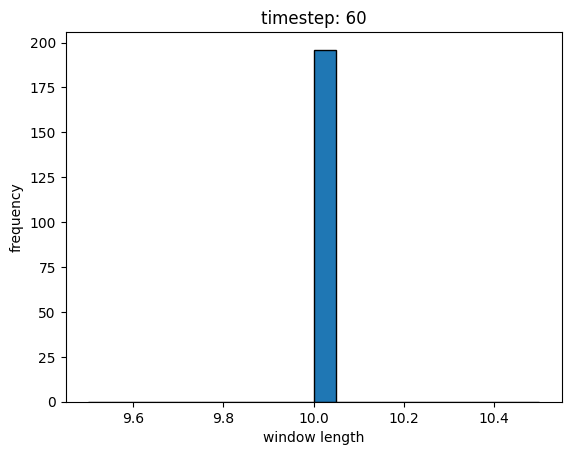

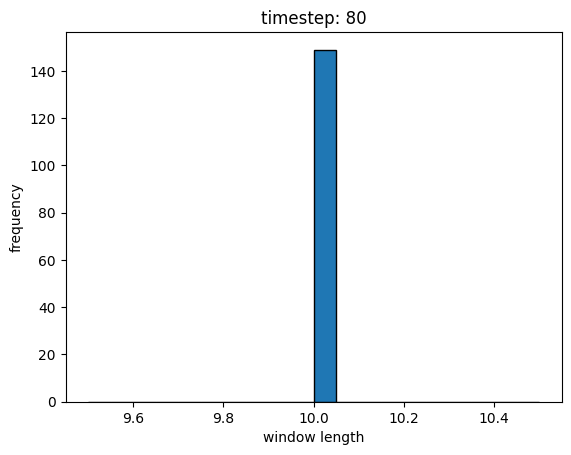

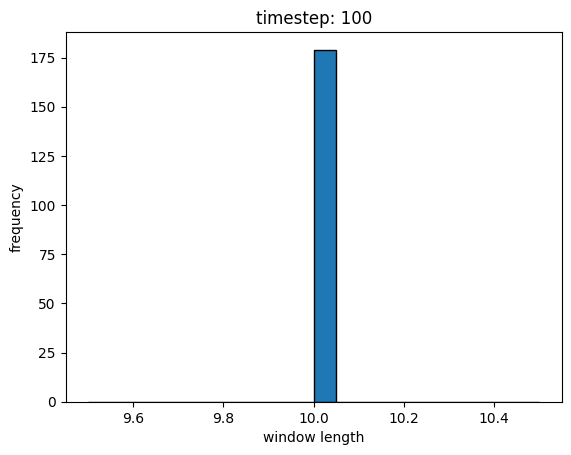

In [ ]:
# double check histogram of lengths in transect
for timestep in timesteps:
    lengths=[stop-start for (start,stop) in split_windows_idx[timestep]]

    plt.hist(lengths,bins=20,edgecolor='black')
    plt.title(f"timestep: {timestep}")
    plt.xlabel("window length")
    plt.ylabel("frequency")

    plt.show()

In [114]:
# store new windows as training and testing of MAE
transects_split=[]
info=[] # (timestep, start, stop)

for timestep in split_windows_idx:
    transect=transect_df_raw[timestep].values

    for (start,stop) in split_windows_idx[timestep]: #loop through all window image pairs 
        window=transect[start:stop]

        if len(window)==(stop-start): #double check window length is right
            transects_split.append(window)
            info.append((timestep,start,stop)) #where window came from info

In [115]:
transects_split=np.array(transects_split)

In [116]:
print(transects_split.shape) # number of windows, length of windows
# this is total amount of possible training,testing,val data

(37686, 10)


In [117]:
# split into training, testing, and validation data
timesteps=sorted(split_windows_idx.keys()) # list of timesteps in order

# split up by time
n=len(timesteps)

train_end=int(n*0.7) #first 70% training
val_end=int(n*0.85) # then 15% validation

train_time=timesteps[:train_end] 
val_time=timesteps[train_end:val_end]
test_time=timesteps[val_end:] #15% test

X_train, X_test, X_val = [], [], []
for t in train_time:
    transect=transect_df_raw[t].values
    for (start,stop) in split_windows_idx[t]:
        X_train.append(transect[start:stop])

for t in val_time:
    transect=transect_df_raw[t].values
    for (start,stop) in split_windows_idx[t]:
        X_val.append(transect[start:stop])

for t in test_time:
    transect=transect_df_raw[t].values
    for (start,stop) in split_windows_idx[t]:
        X_test.append(transect[start:stop])

In [118]:
# convert datat to arrays for MAE
X_train=np.array(X_train)
X_train=X_train.astype("float32")
X_test=np.array(X_test)
X_test=X_test.astype("float32")
X_val=np.array(X_val)
X_val=X_val.astype("float32")

In [119]:
# normalize data
avg=X_train.mean()
std=X_train.std()

X_train=(X_train-avg)/std
X_test=(X_test-avg)/std
X_val=(X_val-avg)/std

In [120]:
# define model
# right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
class Denoise(Model):
    def __init__(self):
        super(Denoise,self).__init__()

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(None,2)),
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2)
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Conv1D(1,3,activation=None,padding='same'),
            layers.Cropping1D((0,6)) # builds up to 16, need length of 10
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
autoencoder=Denoise()
autoencoder.compile(optimizer='adam',loss='mse')

def gap_mask(x,mask_ratio):
     length=tf.shape(x)[0]# number of things in x
     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window
     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     mask=tf.ones_like(x)

     idx=tf.range(start,start+gap_size)
     idx=tf.expand_dims(idx,axis=1) #add dimension (block_size,1)

     updates=tf.zeros((gap_size,1),dtype=tf.float32)# zeros at made gaps
     mask=tf.tensor_scatter_nd_update(mask,idx,updates)
     
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x):
    x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x #check right shape or add dimension (length,1)
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

    # mask as a second channel
    x_input=tf.concat([x_masked,mask],axis=-1) # now (length,2)

    return x_input,x # (given data and target/real og data)

In [121]:
# test masking function
x=tf.ones((10,1))
x_masked,mask=gap_mask(x,0.5)

print("x masked:",x_masked.numpy().flatten())
print("mask:",mask.numpy().flatten())

x masked: [1. 1. 0. 0. 0. 0. 0. 1. 1. 1.]
mask: [1. 1. 0. 0. 0. 0. 0. 1. 1. 1.]


In [122]:
print(X_train.shape)

(26361, 10)


In [123]:
print(X_val.shape)

(6127, 10)


In [124]:
batch_size=16
# grab data from X_train, mask, .AUTOTUNE oarallelizes (for speed? via internet), batch groups of 16, prefetch preps next batch while training on the 1st
train_ds=(
    tf.data.Dataset.from_tensor_slices(X_train).map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE))

val_ds=(
    tf.data.Dataset.from_tensor_slices(X_val).map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE))

In [125]:
# check size of ds
for x_input, y in train_ds.take(1):
    print("x input shape",x_input.shape) #(batch,length,2)
    print("y shape:", y.shape) #(batch, length, 1)

x input shape (16, 10, 2)
y shape: (16, 10, 1)


In [126]:
#TRAIN

autoencoder=Denoise()
autoencoder.compile(optimizer='adam',loss='mse')

history=autoencoder.fit(train_ds,validation_data=val_ds,epochs=150)

Epoch 1/150
1648/1648 [==============================] - 12s 7ms/step - loss: 0.1198 - val_loss: 0.0200
Epoch 2/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0314 - val_loss: 0.0231
Epoch 3/150
1648/1648 [==============================] - 12s 7ms/step - loss: 0.0246 - val_loss: 0.0139
Epoch 4/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0194 - val_loss: 0.0174
Epoch 5/150
1648/1648 [==============================] - 12s 7ms/step - loss: 0.0239 - val_loss: 0.0142
Epoch 6/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0198 - val_loss: 0.0153
Epoch 7/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0198 - val_loss: 0.0153
Epoch 8/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0139 - val_loss: 0.0127
Epoch 9/150
1648/1648 [==============================] - 11s 7ms/step - loss: 0.0187 - val_loss: 0.0135
Epoch 10/150
1648/1648 [==============================] - 11s 7m

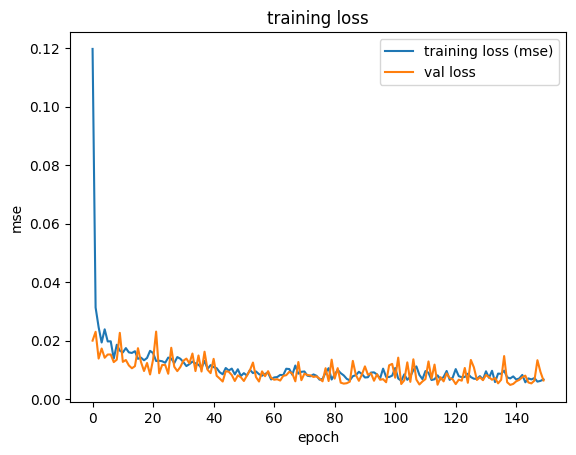

In [127]:
# plot loss curve
# plot training loss
plt.figure()
plt.plot(history.history['loss'],label='training loss (mse)')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel('mse')
plt.title('training loss')
plt.show()

# training loss shows how it's learning (rapid learning then levels off) Val loss shows how model performs on unseen data (it's decreasing so yay!)

In [128]:
# evaluate on gaps

def gap_eval(model,ds):
    total_error=0
    count=0

    for x_input, y_true in ds:
        x_masked=x_input[...,0:1] #input with masked vals
        mask=x_input[...,1:2]

        y_pred=model(x_input)

        gap=1-mask # gap1 mask0
        error=tf.reduce_sum(tf.abs((y_true-y_pred)*gap)) #recon error only at masks mean abs error
        total_error+=error
        count+=tf.reduce_sum(gap)

    return total_error/count #avg error over masked gaps
    
gap_Meanabserr=gap_eval(autoencoder,val_ds)
print("GAP Mean abs error:",gap_Meanabserr.numpy())

GAP Mean squeared error: 0.051347


In [129]:
# test on full transects

def recon_gaps(model,x,mask):
    # x is (551,239)
    # mask is (551,1)
    x_masked=x*mask
    x_input=tf.concat([x_masked,mask],axis=-1)# smoosh last dim (551,239+1mask dim)

    recon=model.predict(x_input[None,...])[0]#add batch dim,predict,delete batch dim

    filled=x*mask+recon*(1-mask)#where mask =1 filled is x, but when mask is 0 filled is reconstruction
    return filled


In [130]:
def prep_input_data(x,mask):
    x=tf.convert_to_tensor(x,dtype=tf.float32)
    mask=tf.convert_to_tensor(mask,dtype=tf.float32)
    # make sure (length,)
    x=tf.reshape(x,[-1])
    mask=tf.reshape(mask,[-1])
    #expand to shape (length,1)
    x=tf.expand_dims(x,-1)
    mask=tf.expand_dims(mask,-1)

    x_masked=x*mask #zeros where Nans are
    # final shape is (length,2)
    x_input=tf.concat([x_masked,mask],axis=-1)

    return x_input


In [131]:
# try sliding windows over the transect filling and putting back together
def recon_full_transects_w_windows(model,x,mask,window_size,stride=5):
    recon=np.zeros_like(x)
    countrs=np.zeros_like(x)

    for i in range(0,len(x)-window_size+1,stride):#window across transect
        x_win=x[i:i+window_size].reshape(-1) #in 1d
        m_win=mask[i:i+window_size].reshape(-1)

        x_input=prep_input_data(x_win,m_win) #(length,2) is now (val,mask)
        pred=model.predict(x_input[None,...])[0].squeeze(-1) #add batch dim, pred,remove batch dim,remove channel dim (window_size,1)

        recon[i:i+window_size]+=pred #add predictions to reconstruction
        countrs[i:i+window_size] +=1

    return recon/np.maximum(countrs,1) #avg pred per point (since overlap)
#stride=overlap b/w windows

In [ ]:
x=tf.convert_to_tensor(transect_df_raw.values,dtype=tf.float32) # (num points along transect, num timesteps)

reconstructed_all=[]

for i in range(x.shape[1]): 
    x_1dim=x[:,i]
    mask_1dim=tf.cast(~tf.math.is_nan(x_1dim),tf.float32) # mask 1 = data good, mask =0 no data
    x_1dim=tf.where(tf.math.is_nan(x_1dim),0.0,x_1dim)# no nans
    #side window function
    recon=recon_full_transects_w_windows(autoencoder,x_1dim.numpy(),mask_1dim.numpy(),10,5)

    reconstructed_all.append(recon)

reconstructed_all=np.stack(reconstructed_all,axis=1)#array

1/1 [==============================] - 0s 14ms/step


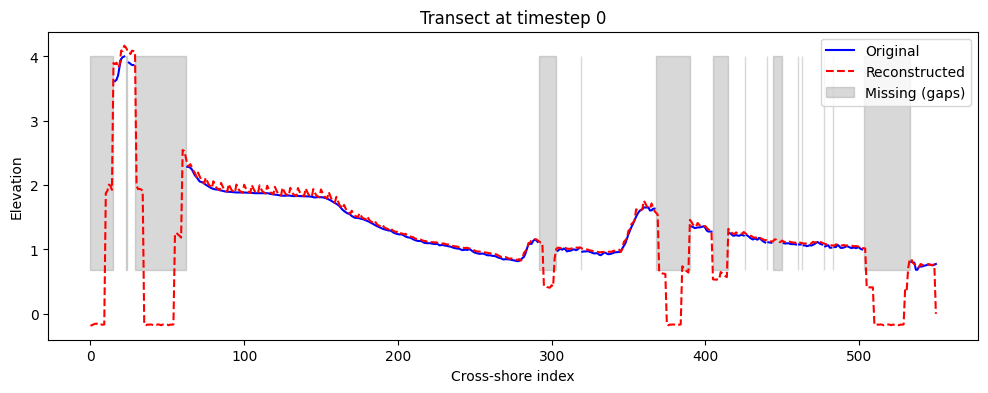

In [ ]:
t = 0  # choose timestep

original = transect_df_raw.values[:, t]
recon = reconstructed_all[:, t]

mask = ~np.isnan(original)

plt.figure(figsize=(12,4))

plt.plot(original, label="Original", color="blue")
plt.plot(recon, label="Reconstructed", color="red", linestyle="--")

# highlight missing regions
plt.fill_between(
    np.arange(len(original)),
    np.nanmin(original),
    np.nanmax(original),
    where=~mask,
    color='gray',
    alpha=0.3,
    label="Missing Gaps"
)

plt.title(f"Transect at timestep {t}")
plt.xlabel("Cross-shore index")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

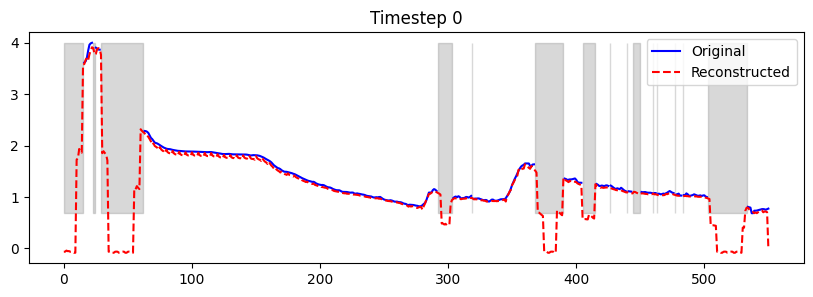

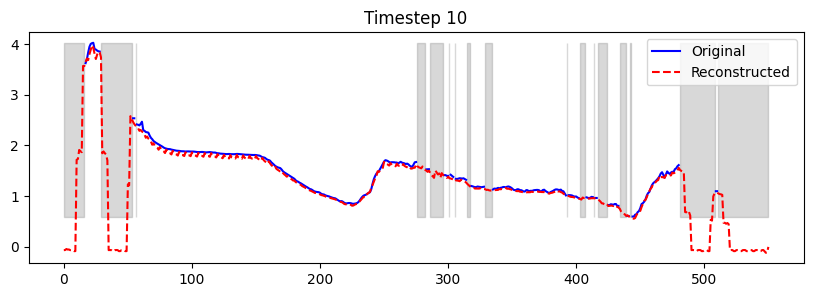

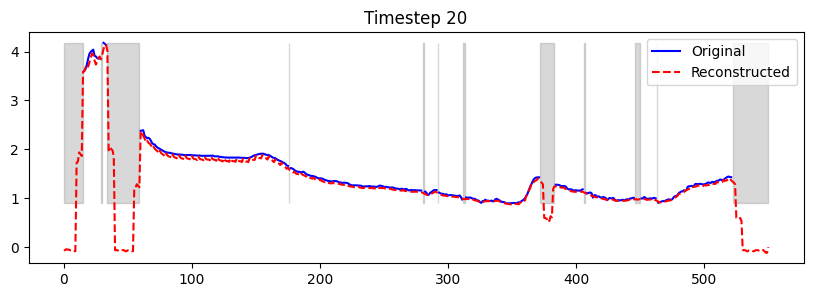

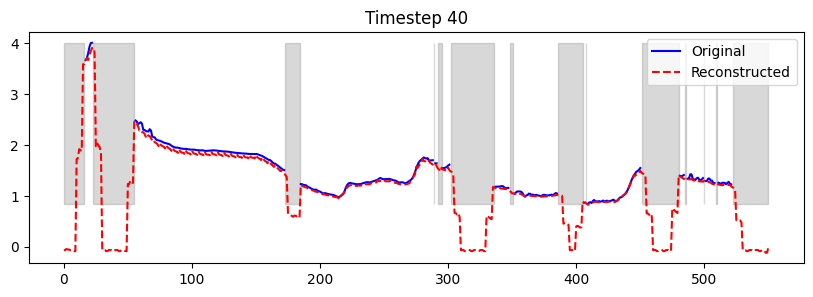

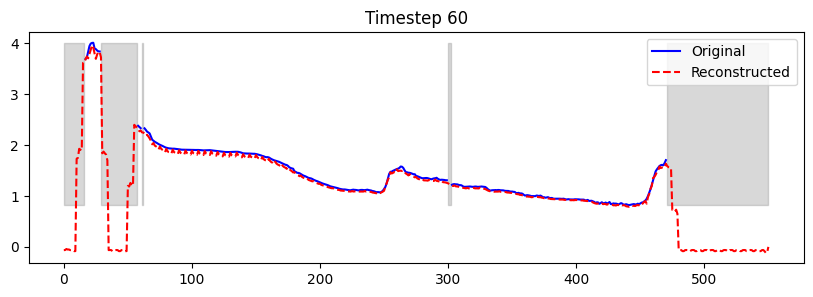

In [100]:
timesteps = [0, 10, 20, 40, 60]

for t in timesteps:
    original = transect_df_raw.values[:, t]
    recon = reconstructed_all[:, t]
    mask = ~np.isnan(original)

    plt.figure(figsize=(10,3))

    plt.plot(original, color='blue', label='Original')
    plt.plot(recon, color='red', linestyle='--', label='Reconstructed')

    plt.fill_between(
        np.arange(len(original)),
        np.nanmin(original),
        np.nanmax(original),
        where=~mask,
        color='gray',
        alpha=0.3
    )

    plt.title(f"Transect at timestep {t}")
    plt.xlabel("Cross-shore index")
    plt.ylabel("Elevation (m)")
    plt.legend()
    plt.show()

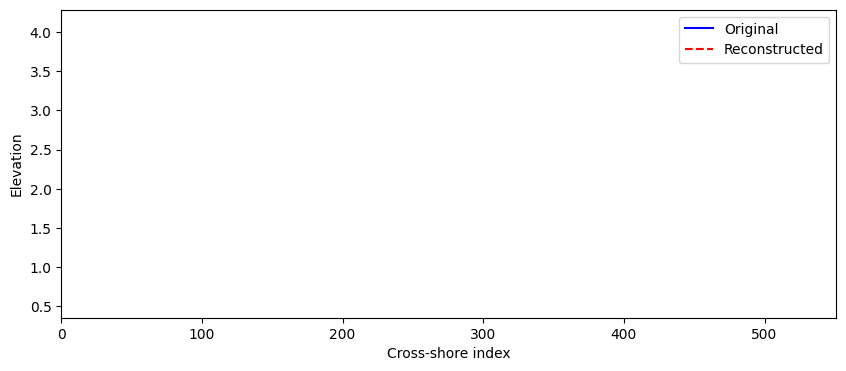

In [ ]:
orig = transect_df_raw.values          # (n_points, n_timesteps)
recon = reconstructed_all              # same shape

from matplotlib.animation import FuncAnimation
# vid of trans
n_points, n_timesteps = orig.shape
x = np.arange(n_points)

fig, ax = plt.subplots(figsize=(10,4))

line_orig, = ax.plot([], [], color='blue', label='Original')
line_recon, = ax.plot([], [], color='red', linestyle='--', label='Reconstructed')
gap_fill = None

ax.set_xlim(0, n_points)
ax.set_ylim(np.nanmin(orig), np.nanmax(orig))
ax.set_xlabel("Cross-shore index")
ax.set_ylabel("Elevation (m)")
ax.legend()

def update(t):
    global gap_fill

    y_orig = orig[:, t]
    y_recon = recon[:, t]

    mask = ~np.isnan(y_orig)

    line_orig.set_data(x, y_orig)
    line_recon.set_data(x, y_recon)

    if gap_fill:
        gap_fill.remove()

    gap_fill = ax.fill_between(
        x,
        np.nanmin(orig),
        np.nanmax(orig),
        where=~mask,
        color='gray',
        alpha=0.3
    )

    ax.set_title(f"Timestep {t}")

    return line_orig, line_recon

anim = FuncAnimation(fig, update, frames=n_timesteps, interval=200)

plt.show()


In [108]:
print(anim.writers.list())

AttributeError: 'FuncAnimation' object has no attribute 'writers'

In [109]:
from matplotlib.animation import FFMpegWriter
writer = FFMpegWriter(fps=5)

In [111]:
anim.save("transects_recon_window10.gif",writer="pillow")

In [110]:
anim.save("transects_animation_window10.mp4", fps=5)

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

In [79]:
autoencoder.summary()

Model: "denoise_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_16 (Sequential)  (None, 2, 8)              2168      
                                                                 
 sequential_17 (Sequential)  (None, 10, 1)             2265      
                                                                 
Total params: 4433 (17.32 KB)
Trainable params: 4433 (17.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


OLD

In [241]:
# trying to animate reconstruction

class ReconstructionLogger(tf.keras.callbacks.Callback):
    def __init__(self,sample_batch):
        super().__init__()
        self.sample_batch=sample_batch
        self.history=[]

    def on_epoch_end(self,epoch,logs=None):
        recons=self.model(self.sample_batch)
        self.history.append(recons.numpy())

In [242]:
for x_sample,y_sample in train_ds.take(1):
    break

recon_logger=ReconstructionLogger(x_sample)
# just grab one batch

In [243]:
# start masking at 10% and work you way up
autoencoder=Denoise()
autoencoder.compile(optimizer='adam',loss='mse')

history=autoencoder.fit(
    train_ds,
    epochs=150,
    validation_data=val_ds,
    callbacks=[recon_logger]
)

Epoch 1/150
1648/1648 [==============================] - 22s 13ms/step - loss: 0.0829 - val_loss: 0.0105
Epoch 2/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0109 - val_loss: 0.0167
Epoch 3/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0087 - val_loss: 0.0035
Epoch 4/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0075 - val_loss: 0.0056
Epoch 5/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0085 - val_loss: 0.0030
Epoch 6/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 7/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0090 - val_loss: 0.0025
Epoch 8/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 9/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0044 - val_loss: 0.0050
Epoch 10/150
1648/1648 [==============================]

In [244]:
for x_sample,y_sample in train_ds.take(1):
    x_batch,y_batch=x_sample,y_sample

for x_batch in val_ds.take(1):
    recons=autoencoder.predict(x_batch)

ValueError: in user code:

    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2341, in predict_function  *
        return step_function(self, iterator)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2327, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2315, in run_step  **
        outputs = model.predict_step(data)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2283, in predict_step
        return self(x, training=False)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/var/folders/q5/f29tpv4

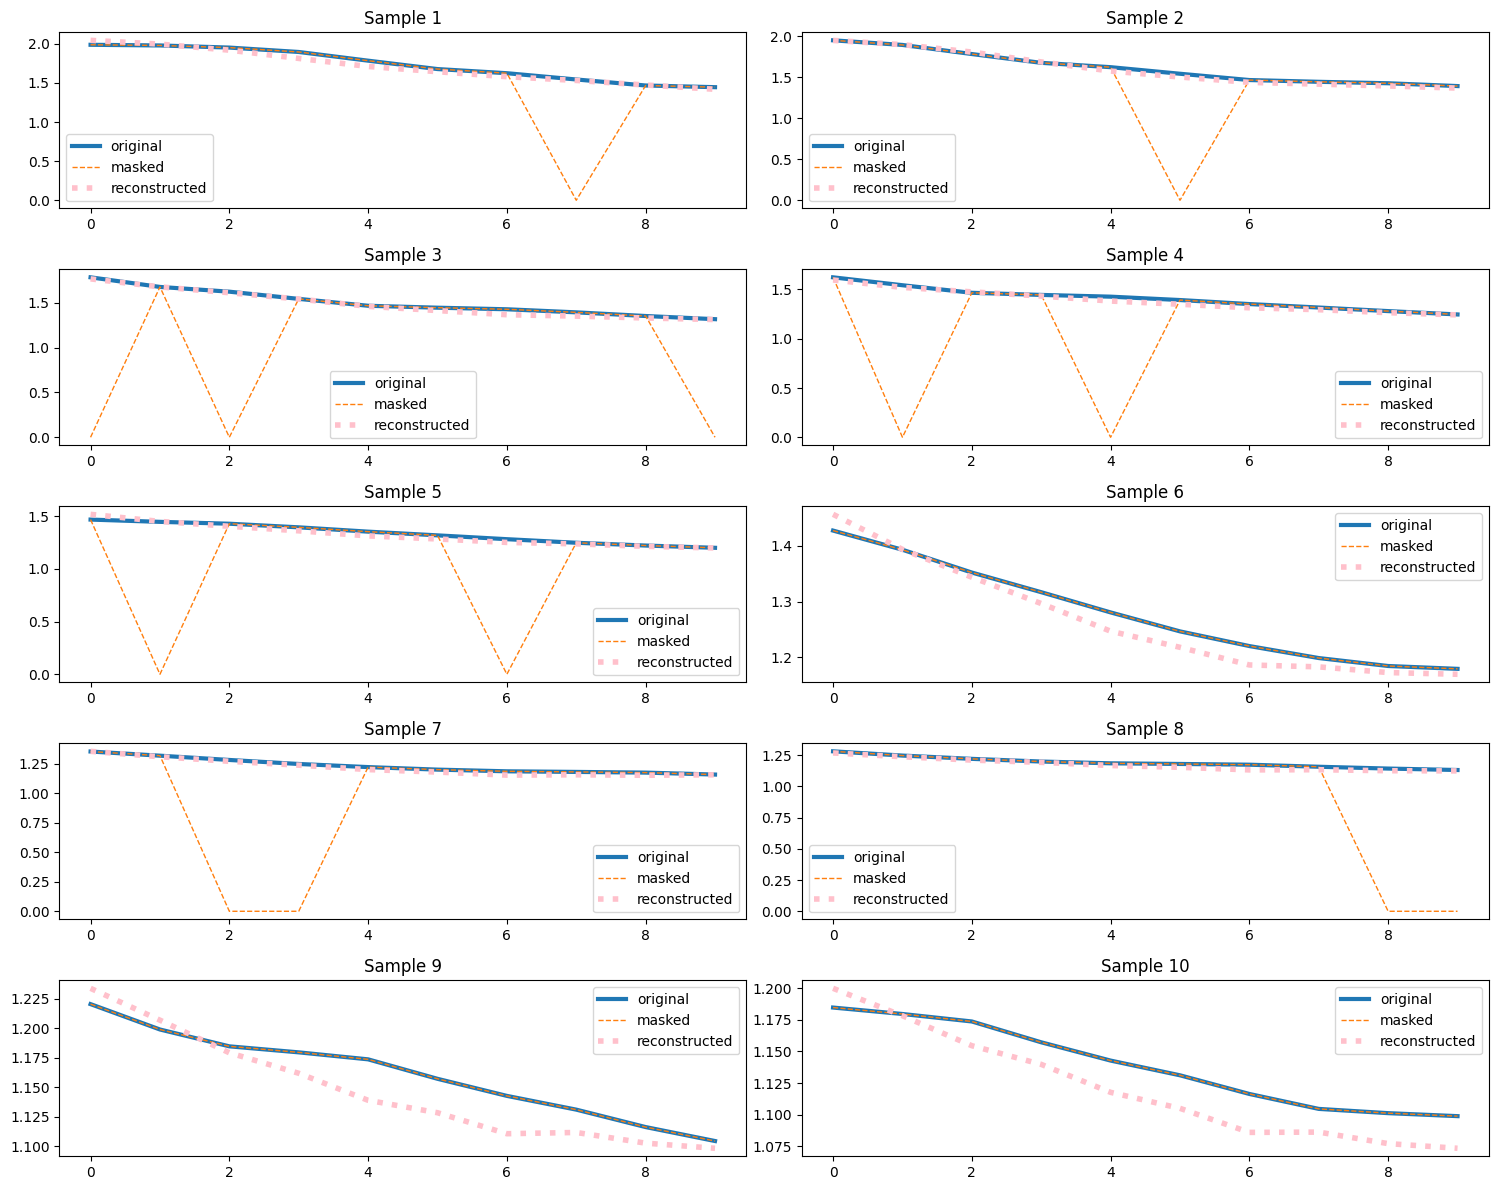

In [223]:
# plotting 
n=10

fig,axes=plt.subplots(nrows=5,ncols=2,figsize=(15,12))
axes=axes.flatten()

for i in range(n):
    #remove channel dimension
    x=x_batch[i].numpy().squeeze()
    y=y_batch[i].numpy().squeeze()
    recon=reconstructed_batch[i].numpy().squeeze()

    axes[i].plot(y,label='original',linewidth=3)
    axes[i].plot(x,label='masked',linestyle="dashed",linewidth=1)
    axes[i].plot(recon,label='reconstructed',linestyle='dotted',linewidth=4,color='pink')
    axes[i].set_title(f"Sample {i+1}")
    axes[i].legend()

plt.tight_layout()
plt.show()


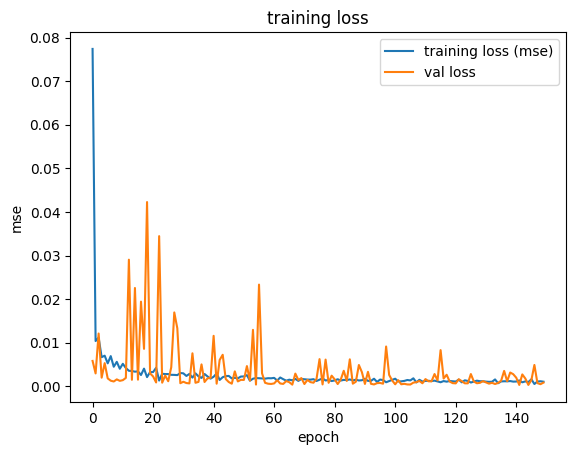

In [224]:
# plot training loss
plt.figure()
plt.plot(history.history['loss'],label='training loss (mse)')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel('mse')
plt.title('training loss')
plt.show()

# training loss shows how it's learning (rapid learning then levels off) Val loss shows how model performs on unseen data (it's decreasing so yay!)

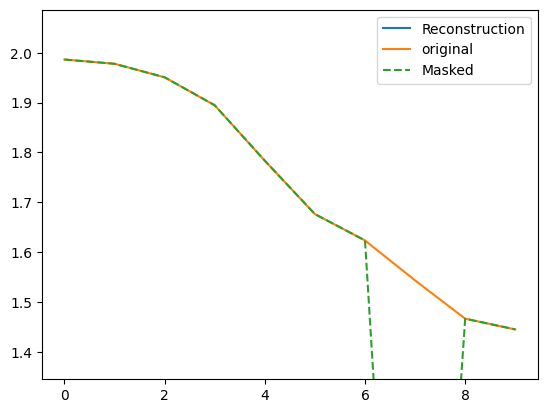

In [225]:
from matplotlib.animation import FuncAnimation

idx=0

y_true=y_sample[idx].numpy().squeeze()
x_input=x_sample[idx].numpy().squeeze()

fig,ax=plt.subplots()

line_recon,=ax.plot([],[],label="Reconstruction")
line_true,=ax.plot(y_true,label='original')
line_input=ax.plot(x_input,linestyle='dashed',label='Masked')

ax.legend()
ax.set_ylim(min(y_true)-0.1,max(y_true)+0.1)

def update(frame):
    recons=recon_logger.history[frame][idx].squeeze()
    line_recon.set_data(range(len(recons)),recons)
    ax.set_title(f"epoch {frame+1}")
    return line_recon,

anim=FuncAnimation(fig,update,frames=len(recon_logger.history),interval=200)

plt.show()

anim.save("reconstruction_01mask_10window.gif",writer="pillow")

In [ ]:
# give MAE the transects and see how it performs

In [ ]:
# increase masking ratio and repeat analysis ( on another notebook maybe)